In [ ]:
import joblib             as jlb
import matplotlib.pyplot  as plt
import pandas             as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # tắt những cảnh báo

from collections           import Counter
from sklearn.decomposition import PCA
from sklearn.cluster       import DBSCAN
from data_processing import D

Tiền xử lý dữ liệu

In [2]:
features=['Income','Age','Total_Spend']
data=D[features].copy()
print(data.shape)
print(data.head(1))

(2229, 3)
     Income       Age  Total_Spend
0  0.316484  1.015715     1.205616


In [3]:
##------------------------------------------------------------------------------
## Xây dựng mô hình DBSCAN
##------------------------------------------------------------------------------
## eps        : bán kính lân cận (neighborhood radius)
## min_samples: số điểm tối thiểu trong lân cận để tạo thành core point
##
## Nhãn cluster = -1 → điểm NHIỄU (noise/outlier), không thuộc cụm nào
##------------------------------------------------------------------------------
model = DBSCAN(eps=0.3, min_samples=10)
model.fit(data)  # xây dựng mô hình

,eps,0.3
,min_samples,10
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [4]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(model,'../customer_clustering/Output/clarans.mdl')

['../customer_clustering/Output/clarans.mdl']

In [5]:
## Khai thác mô hình đã được xây dựng
model = jlb.load('../customer_clustering/Output/clarans.mdl')

In [6]:
## Kết quả gom cụm khách hàng
data['cluster'] = model.labels_
print(data.head(1))
n_clusters = len(set(model.labels_)) - (1 if -1 in model.labels_ else 0)
n_noise    = list(model.labels_).count(-1)

print(f'\nSố clusters tìm được  : {n_clusters}')
print(f'Số điểm nhiễu (noise): {n_noise}')
print('\nKích thước các clusters (bao gồm noise = -1):', Counter(model.labels_))

     Income       Age  Total_Spend  cluster
0  0.316484  1.015715     1.205616        0

Số clusters tìm được  : 3
Số điểm nhiễu (noise): 362

Kích thước các clusters (bao gồm noise = -1): Counter({np.int64(0): 1811, np.int64(-1): 362, np.int64(1): 41, np.int64(2): 15})


In [7]:
for eps in [0.2, 0.3, 0.5, 0.8, 1.0]:
    m          = DBSCAN(eps = eps, min_samples = 10).fit(data)
    n_clusters = len(set(m.labels_)) - (1 if -1 in m.labels_ else 0)
    n_noise    = list(m.labels_).count(-1)
    print(f'eps={eps} → clusters: {n_clusters}, noise: {n_noise}')

eps=0.2 → clusters: 15, noise: 1533
eps=0.3 → clusters: 3, noise: 362
eps=0.5 → clusters: 9, noise: 172
eps=0.8 → clusters: 5, noise: 27
eps=1.0 → clusters: 4, noise: 10


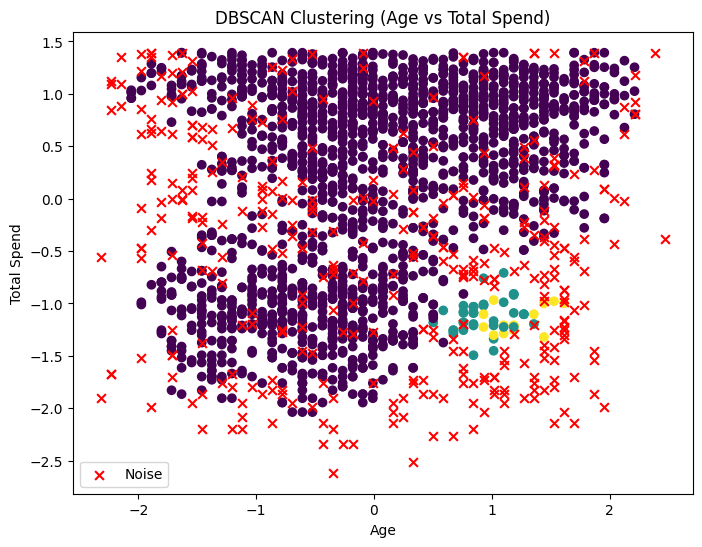

In [8]:
noise    = data[data.cluster == -1]
clusters = data[data.cluster != -1]

plt.figure(figsize=(8, 6))
plt.scatter(clusters['Age'], clusters['Total_Spend'], 
            c=clusters['cluster'])

plt.scatter(noise['Age'], noise['Total_Spend'], 
            c='red', marker='x', s=40, label='Noise')

plt.xlabel('Age')
plt.ylabel('Total Spend')
plt.title('DBSCAN Clustering (Age vs Total Spend)')
plt.legend()
plt.show()

In [9]:
pca=PCA(n_components=2)
pca.fit(data)
PCA_ds=pd.DataFrame(pca.transform(data),columns=['col1','col2'])
PCA_ds['cluster'] = data['cluster']
print(PCA_ds.describe())

               col1          col2      cluster
count  2.229000e+03  2.229000e+03  2229.000000
mean  -3.347106e-17  1.593860e-17    -0.130552
std    1.383765e+00  9.587700e-01     0.436759
min   -3.483067e+00 -2.756731e+00    -1.000000
25%   -1.260057e+00 -6.582738e-01     0.000000
50%    1.709020e-01 -6.559069e-03     0.000000
75%    1.196571e+00  6.823459e-01     0.000000
max    2.956696e+00  2.604720e+00     2.000000


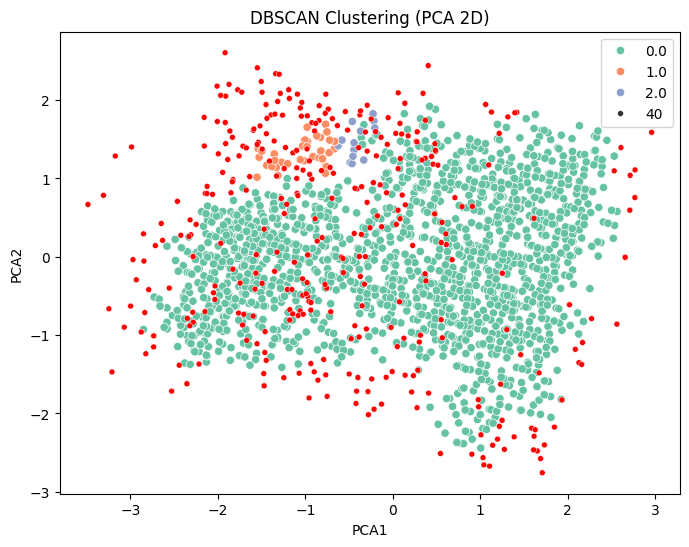

In [10]:
noise_pca    = PCA_ds[PCA_ds.cluster == -1]
clusters_pca = PCA_ds[PCA_ds.cluster != -1]

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=PCA_ds['col1'],
    y=PCA_ds['col2'],
    hue=clusters_pca['cluster'],
    palette='Set2'
)
sns.scatterplot(x=noise_pca['col1'],y=noise_pca['col2'],markers='x',size=40,c='red')

plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('DBSCAN Clustering (PCA 2D)')
plt.legend()
plt.show()